In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from astroquery.simbad import Simbad
import warnings
warnings.filterwarnings('ignore')

print("Loading groups...")
groups = pd.read_pickle("/home/msp25gd/Downloads/res/meta/groups.pkl")
print(f"Loaded {len(groups)} groups")
print(f"\nGroups columns: {groups.columns.tolist()}")
print(f"\nFirst few rows:")
print(groups.head())

Loading groups...
Loaded 12827 groups

Groups columns: ['New Groups', 'OBJECT', 'Sanitised', 'Reduced', 'DEC', 'EXPTIME', 'MJD-OBS', 'MJD-END', 'WAVELMIN', 'WAVELMAX', 'SPEC_BIN', 'SPEC_RES']

First few rows:
   New Groups          OBJECT       Sanitised        Reduced       DEC  \
0           0    $\alpha$-Cru    $\alpha$ Cru    $\alpha$cru -63.09899   
1           1  $\gamma^2$-Vel  $\gamma^2$ Vel  $\gamma^2$vel -47.33665   
2           2    $\theta$-Car    $\theta$ Car    $\theta$car -64.39407   
3           3     $\zeta$-Pup     $\zeta$ Pup     $\zeta$pup -40.00284   
4           4       0003+1713       0003+1713      0003+1713  17.22642   

     EXPTIME       MJD-OBS       MJD-END    WAVELMIN    WAVELMAX  SPEC_BIN  \
0     5.0078  53747.372964  53747.375327  328.195459  456.300129  0.001358   
1     5.0079  53670.279645  53670.281882  328.192145  456.299040  0.001357   
2    10.0084  53686.311039  53686.313337  328.196918  456.298107  0.001356   
3     5.0081  53670.273791  53670.

In [4]:
import re

# Load the quicksearch candidates (reduced names)
qs_candidates = np.load(
    '/home/msp25gd/ResearchProjectMSc/HR/results/QuickSearch/candidates_-4sig_2cut_3width.npy',
    allow_pickle=True
)
print(f"Quicksearch candidates: {len(qs_candidates)}")
print(qs_candidates[:10])

# Look up each candidate in groups.pkl using the Reduced column
# OBJECT is the raw FITS header name — same name iplotter passes to Simbad
metadata = pd.read_pickle("/home/msp25gd/Downloads/res/meta/metadata.pkl")

cand_rows = []
for reduced_name in qs_candidates:
    match = groups[groups['Reduced'] == reduced_name]
    if len(match) > 0:
        cand_rows.append(match.iloc[0])
    else:
        # fall back to metadata if the group lookup misses
        meta_match = metadata[metadata['Reduced'] == reduced_name]
        if len(meta_match) > 0:
            row = meta_match.iloc[0].copy()
            cand_rows.append(row)

candidates_df = pd.DataFrame(cand_rows).reset_index(drop=True)
print(f"\nResolved {len(candidates_df)} / {len(qs_candidates)} candidates")
print(f"Columns: {candidates_df.columns.tolist()}")
print(candidates_df[['OBJECT', 'Sanitised', 'Reduced']].head(10))

Quicksearch candidates: 224
['hd323771' 'vssleo' 'walker67' 'hd124314' 'bpsbs169810016' 'sniaa'
 'rylup' 'hd210121' 'hs1606+0153' 'eicha']

Resolved 224 / 224 candidates
Columns: ['New Groups', 'OBJECT', 'Sanitised', 'Reduced', 'DEC', 'EXPTIME', 'MJD-OBS', 'MJD-END', 'WAVELMIN', 'WAVELMAX', 'SPEC_BIN', 'SPEC_RES']
              OBJECT          Sanitised         Reduced
0          HD-323771          HD 323771        hd323771
1           V SS Leo           V SS Leo          vssleo
2          Walker 67          Walker 67        walker67
3          HD 124314          HD 124314        hd124314
4  BPS BS 16981-0016  BPS BS 16981 0016  bpsbs169810016
5            SN Ia A            SN Ia A           sniaa
6             RY-Lup             RY Lup           rylup
7           HD210121           HD210121        hd210121
8        hs1606+0153        hs1606+0153     hs1606+0153
9              EICha              EICha           eicha


In [5]:
# Query Simbad for spectral types using the OBJECT name
# (same approach as iplotter's get_otypes — this name is what Simbad knows)
from astroquery.simbad import Simbad

simbad = Simbad()
simbad.add_votable_fields('sp_type')
simbad.TIMEOUT = 120

print(f"Querying Simbad for {len(candidates_df)} candidates...\n")

sp_types = []
for idx, row in candidates_df.iterrows():
    object_name = row['OBJECT']
    try:
        result = simbad.query_object(object_name)
        if result is not None and len(result) > 0 and 'sp_type' in result.colnames:
            sp_type = str(result['sp_type'][0]).strip()
            sp_types.append(sp_type if sp_type else None)
        else:
            sp_types.append(None)
    except Exception:
        sp_types.append(None)
    print(f"  {idx+1:>3}/{len(candidates_df)}  {object_name:<30}  {sp_types[-1]}")

candidates_df['sp_type'] = sp_types

found = sum(1 for x in sp_types if x)
print(f"\nSpectral types found: {found} / {len(candidates_df)}")

Querying Simbad for 224 candidates...

    1/224  HD-323771                       None
    2/224  V SS Leo                        None
    3/224  Walker 67                       B1V
    4/224  HD 124314                       O6V(n)((f))
    5/224  BPS BS 16981-0016               sdB
    6/224  SN Ia A                         None
    7/224  RY-Lup                          None
    8/224  HD210121                        B7II
    9/224  hs1606+0153                     DA3+dM
   10/224  EICha                           None
   11/224  HD 78344                        O9.5/B0(Ib)
   12/224  HR                              None
   13/224  51-Oph                          None
   14/224  LMC-SC6-57364                   None
   15/224  HR5027                          B0.5Ia
   16/224  bet Pic                         A6V
   17/224  HD-51876                        None
   18/224  2A-1822-371                     None
   19/224  HR6788                          B2II/III
   20/224  HD150136           

In [ ]:
import matplotlib.pyplot as plt

# Extract spectral class (first letter) from full spectral type string
CLASS_ORDER = ['O', 'B', 'A', 'F', 'G', 'K', 'M', 'W', 'C', 'S', 'Other', 'Unknown']
CLASS_COLORS = {
    'O': '#3355FF', 'B': '#6699FF', 'A': '#AADDFF',
    'F': '#CCFFEE', 'G': '#FFFF44', 'K': '#FF9900',
    'M': '#FF3333', 'W': '#FF99FF', 'C': '#8B5A2B',
    'S': '#FF6699', 'Other': '#BBBBBB', 'Unknown': '#888888'
}

def to_class(sp_type):
    if not sp_type or str(sp_type).strip() in ('', 'None', 'nan', '--'):
        return 'Unknown'
    letter = sp_type[0].upper()
    return letter if letter in list('OBAFGKMWCS') else 'Other'

candidates_df['sp_class'] = candidates_df['sp_type'].apply(to_class)

counts = candidates_df['sp_class'].value_counts()
# Preserve canonical order, dropping absent classes
present = [c for c in CLASS_ORDER if c in counts]
values  = [counts[c] for c in present]
colors  = [CLASS_COLORS[c] for c in present]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(present, values, color=colors, edgecolor='black', linewidth=1.2)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xlabel('Spectral Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Stars', fontsize=12, fontweight='bold')
ax.set_title(
    f'Spectral Type Distribution of QuickSearch Candidates\n'
    f'({len(candidates_df)} candidates from {len(qs_candidates)} total)',
    fontsize=13, fontweight='bold', pad=15
)
ax.grid(axis='y', alpha=0.35, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('/home/msp25gd/ResearchProjectMSc/stats/spectral_type_quicksearch.png',
            dpi=300, bbox_inches='tight')
plt.show()

# Summary table
known_total = sum(v for c, v in zip(present, values) if c not in ('Unknown', 'Other'))
print(f"\n{'Class':<8} {'Count':<8} {'%'}")
print('-' * 28)
for cls, val in zip(present, values):
    pct = f'{100*val/known_total:.1f}%' if cls not in ('Unknown', 'Other') else 'N/A'
    print(f"{cls:<8} {val:<8} {pct}")

Raw sample summary
------------------
Metadata source: /home/msp25gd/Downloads/res/meta/full_metadata.pkl
Total spectra in sample: 32308
Total groups: 12827

Percentage of groups with less than 3 spectra: 77.49%
Percentage of groups with less than 10 spectra: 96.36%
Groups with >= 3 spectra: 2887 (22.51%)


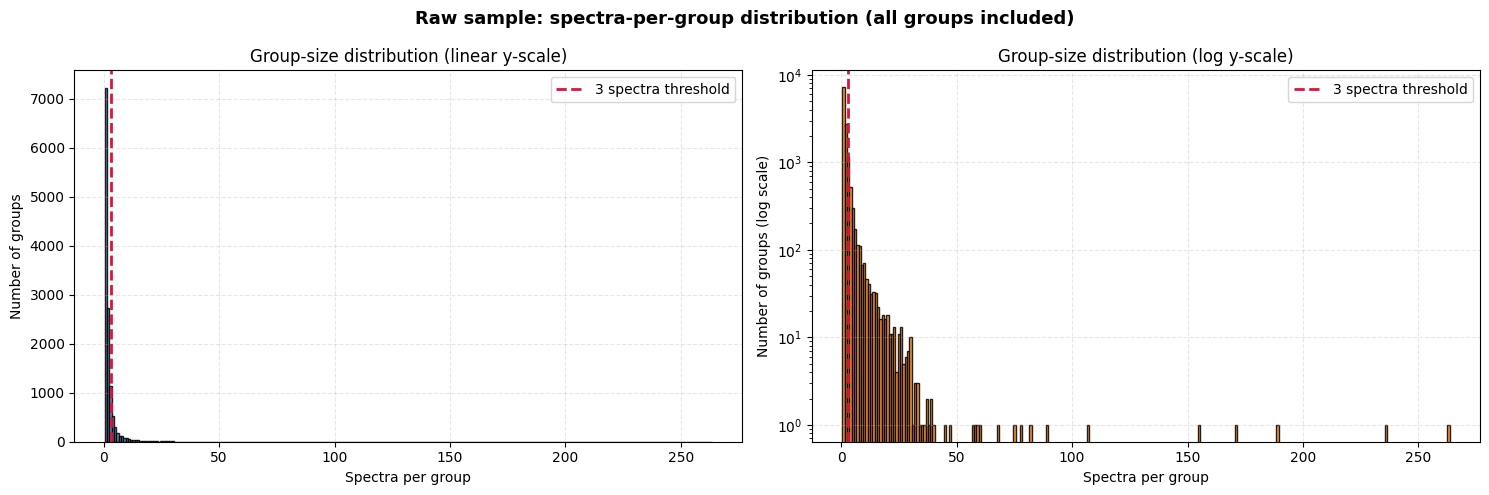

,group_name,spectra_per_group
0,$\alpha$cru,1
1,$\gamma^2$vel,1
2,$\theta$car,1
3,$\zeta$pup,1
4,0003+1713,2


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Prefer full metadata for raw-sample assessment; fall back to metadata.pkl if needed.
candidate_paths = [
    '/home/msp25gd/Downloads/res/meta/full_metadata.pkl',
    '/home/msp25gd/Downloads/res/meta/metadata.pkl',
]

metadata_path = next((p for p in candidate_paths if os.path.exists(p)), None)
if metadata_path is None:
    raise FileNotFoundError('Could not find full_metadata.pkl or metadata.pkl in /home/msp25gd/Downloads/res/meta/')

meta_df = pd.read_pickle(metadata_path).copy()

# Resolve grouping column.
group_col = None
for c in ['Reduced', 'reduced', 'New Groups']:
    if c in meta_df.columns:
        group_col = c
        break
if group_col is None:
    raise KeyError('Could not find a grouping column (Reduced/reduced/New Groups).')

# Count spectra per group across the full sample (includes groups with <3 spectra).
group_sizes = meta_df.groupby(group_col, dropna=False).size().rename('spectra_per_group')

total_groups = int(group_sizes.shape[0])
total_spectra = int(meta_df.shape[0])
groups_lt3 = int((group_sizes < 3).sum())
groups_lt10 = int((group_sizes < 10).sum())
groups_ge3 = int((group_sizes >= 3).sum())

pct_lt3 = 100 * groups_lt3 / total_groups
pct_lt10 = 100 * groups_lt10 / total_groups

summary_text = (
    f'Raw sample summary\n'
    f'------------------\n'
    f'Metadata source: {metadata_path}\n'
    f'Total spectra in sample: {total_spectra}\n'
    f'Total groups: {total_groups}\n\n'
    f'Percentage of groups with less than 3 spectra: {pct_lt3:.2f}%\n'
    f'Percentage of groups with less than 10 spectra: {pct_lt10:.2f}%'
 )
print(summary_text)
print(f'Groups with >= 3 spectra: {groups_ge3} ({100*groups_ge3/total_groups:.2f}%)')

# Histogram binning at integer group sizes.
max_size = int(group_sizes.max())
bins = np.arange(0.5, max_size + 1.5, 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Linear scale view
axes[0].hist(group_sizes.values, bins=bins, color='#4C78A8', edgecolor='black', alpha=0.85)
axes[0].axvline(3, color='crimson', linestyle='--', linewidth=2, label='3 spectra threshold')
axes[0].set_xlabel('Spectra per group')
axes[0].set_ylabel('Number of groups')
axes[0].set_title('Group-size distribution (linear y-scale)')
axes[0].legend()
axes[0].grid(alpha=0.3, linestyle='--')

# Log-scale view for long tail
axes[1].hist(group_sizes.values, bins=bins, color='#F58518', edgecolor='black', alpha=0.85, log=True)
axes[1].axvline(3, color='crimson', linestyle='--', linewidth=2, label='3 spectra threshold')
axes[1].set_xlabel('Spectra per group')
axes[1].set_ylabel('Number of groups (log scale)')
axes[1].set_title('Group-size distribution (log y-scale)')
axes[1].legend()
axes[1].grid(alpha=0.3, linestyle='--')

fig.suptitle('Raw sample: spectra-per-group distribution (all groups included)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Optional table for downstream use
group_size_table = group_sizes.reset_index().rename(columns={group_col: 'group_name'})
group_size_table.head()

In [37]:
import json
import os
import numpy as np
import pandas as pd
from astropy.time import Time
from IPython import get_ipython
from IPython.display import display

# Keep names defined for static analysis; runtime values are loaded on demand.
ASSET = globals().get('ASSET')
to_reduce = globals().get('to_reduce')


def _load_search_runtime(search_dir='/home/msp25gd/ResearchProjectMSc/HR/search'):
    required = ['ASSET', 'to_reduce']
    missing = [name for name in required if name not in globals()]
    if len(missing) == 0:
        return

    ip = get_ipython()
    if ip is None:
        raise RuntimeError('This helper must run inside a Jupyter notebook kernel.')

    original_cwd = os.getcwd()
    try:
        os.chdir(search_dir)
        for nb_name in ['asset.ipynb', 'reduce_name.ipynb']:
            nb_path = os.path.join(search_dir, nb_name)
            if not os.path.exists(nb_path):
                raise FileNotFoundError(f'Missing required notebook: {nb_path}')
            ip.run_line_magic('run', nb_path)
    finally:
        os.chdir(original_cwd)


def _row_to_datetime(row):
    if 'MJD-OBS' in row.index and pd.notna(row['MJD-OBS']):
        try:
            mjd_value = float(row['MJD-OBS'])
            return pd.Timestamp(Time(mjd_value, format='mjd', scale='utc').to_datetime())
        except Exception:
            pass

    for col in ['Date', 'DATE-OBS', 'DATE_OBS', 'Datetime', 'DATE']:
        if col in row.index and pd.notna(row[col]):
            dt = pd.to_datetime(row[col], errors='coerce', utc=True)
            if pd.notna(dt):
                return pd.Timestamp(dt)

    return pd.NaT


def _row_duration_seconds(row):
    if 'MJD-OBS' in row.index and 'MJD-END' in row.index:
        if pd.notna(row['MJD-OBS']) and pd.notna(row['MJD-END']):
            try:
                duration_seconds = (float(row['MJD-END']) - float(row['MJD-OBS'])) * 86400.0
                if np.isfinite(duration_seconds) and duration_seconds > 0:
                    return float(duration_seconds)
            except Exception:
                pass

    if 'EXPTIME' in row.index and pd.notna(row['EXPTIME']):
        try:
            exptime = float(row['EXPTIME'])
            if np.isfinite(exptime) and exptime > 0:
                return float(exptime)
        except Exception:
            pass

    return np.nan


def _format_duration(duration_seconds):
    if pd.isna(duration_seconds):
        return 'Unknown'

    total_seconds = int(round(float(duration_seconds)))
    hours, remainder = divmod(total_seconds, 3600)
    minutes, seconds = divmod(remainder, 60)

    if hours > 0:
        return f'{hours}h {minutes}m {seconds}s'
    if minutes > 0:
        return f'{minutes}m {seconds}s'
    return f'{seconds}s'


def describe_star_detections(
    star_number,
    line='K',
    dataset_root='/home/msp25gd/ResearchProjectMSc/ResolutionHandling/processed_candidates/',
    param_path='/home/msp25gd/ResearchProjectMSc/HR/search/param.json',
    search_dir='/home/msp25gd/ResearchProjectMSc/HR/search',
    date_format='%d/%m/%Y %H:%M:%S',
    show=True,
):
    """Return a readable detection summary and a detected-spectra table for one star."""
    _load_search_runtime(search_dir=search_dir)

    asset_cls = globals().get('ASSET')
    reduce_fn = globals().get('to_reduce')
    if asset_cls is None or reduce_fn is None:
        raise RuntimeError('ASSET/to_reduce helpers are unavailable. Ensure asset.ipynb and reduce_name.ipynb can be loaded.')

    if not os.path.exists(param_path):
        raise FileNotFoundError(f'param.json not found: {param_path}')
    if not os.path.isdir(dataset_root):
        raise FileNotFoundError(f'dataset_root not found: {dataset_root}')

    with open(param_path) as file_obj:
        param = json.load(file_obj)
    param['dataset'] = dataset_root if dataset_root.endswith('/') else dataset_root + '/'

    reduced_name = reduce_fn(str(star_number))
    star_path = os.path.join(param['dataset'], reduced_name)

    if not os.path.isdir(star_path):
        raise FileNotFoundError(
            f"Star folder not found in dataset: {star_path}. Check the star identifier '{star_number}'."
        )

    search = asset_cls(parameters=param, line=line)
    search.ccf = False
    spec_param = search.spec_analysis(star_path + '/')

    if spec_param is None:
        raise ValueError(f'Not enough spectra to analyse detections for {reduced_name}.')

    new_spectra, med, med_err = spec_param

    if not hasattr(search, 'df') or search.df is None:
        raise RuntimeError('ASSET did not expose the metadata table (search.df).')

    spectra_table = search.df.copy().reset_index(drop=True)
    if len(spectra_table) != len(new_spectra):
        raise RuntimeError(
            f'Row mismatch: metadata rows={len(spectra_table)} vs spectra={len(new_spectra)}'
        )

    detection_flags = []
    dip_significance = []
    heliocentric_velocity = []

    for index, spectrum in enumerate(new_spectra):
        snr = search.snr(spectrum, med, search.spectra_err[index], med_err)
        scatter = np.std(snr)
        corr_snr = snr.copy()[search.snr_idxrange]
        sigma = corr_snr / scatter
        min_sigma = float(np.nanmin(sigma))
        filtered_rv = search.radial_velocity[search.snr_idxrange]
        rv_at_minimum = float(filtered_rv[np.nanargmin(sigma)])
        width = float(search.get_width(sigma)) if min_sigma < search.threshold else 0.0
        is_detection = (min_sigma < search.threshold) and (width >= search.width_filter)

        detection_flags.append(bool(is_detection))
        dip_significance.append(min_sigma)
        heliocentric_velocity.append(rv_at_minimum)

    spectra_table['ObservationDateTimeUTC'] = spectra_table.apply(_row_to_datetime, axis=1)
    spectra_table['ObservationDurationSeconds'] = spectra_table.apply(_row_duration_seconds, axis=1)
    spectra_table['Detection'] = detection_flags
    spectra_table['DipSignificanceSigma'] = dip_significance
    spectra_table['HeliocentricVelocity_km_s'] = heliocentric_velocity

    detected_only = spectra_table[spectra_table['Detection']].copy().reset_index(drop=True)
    detected_only['Date'] = detected_only['ObservationDateTimeUTC'].apply(
        lambda value: value.strftime(date_format) if pd.notna(value) else 'Unknown'
    )
    detected_only['DetectionDuration'] = detected_only['ObservationDurationSeconds'].apply(_format_duration)
    detected_only['DipSignificanceSigma'] = detected_only['DipSignificanceSigma'].round(2)
    detected_only['HeliocentricVelocity_km_s'] = detected_only['HeliocentricVelocity_km_s'].round(2)

    output_table = detected_only[
        ['Date', 'DetectionDuration', 'DipSignificanceSigma', 'HeliocentricVelocity_km_s']
    ].rename(
        columns={
            'DipSignificanceSigma': 'DipSignificance (sigma)',
            'HeliocentricVelocity_km_s': 'HeliocentricVelocity (km/s)',
        }
    )

    total_spectra = int(len(spectra_table))
    detected_spectra = int(len(output_table))

    summary_text = (
        f"Star {reduced_name} has {total_spectra} spectra in total, "
        f"and {detected_spectra} of them contain a detection."
    )

    if show:
        print(summary_text)
        if detected_spectra == 0:
            print('No detected spectra were found for this star.')
        else:
            display(output_table)

    return summary_text, output_table

In [38]:
summary_text, detected_spectra_table = describe_star_detections('twhya')

Star twhya has 3 spectra in total, and 2 of them contain a detection.


,Date,DetectionDuration,DipSignificance (sigma),HeliocentricVelocity (km/s)
0,16/04/2000 23:37:46,31m 40s,-4.32,-13.35
1,17/04/2000 23:17:56,31m 40s,-7.08,20.98


All-group distribution summary
------------------------------
Metadata source: /home/msp25gd/Downloads/res/meta/full_metadata.pkl
Total number of groups: 12827
Mean spectra per group: 2.52
Median spectra per group: 1.00
Percentage of groups with < 3 spectra: 77.49%
Percentage of groups with < 10 spectra: 96.36%
Percentage of groups with < 20 spectra: 98.89%
Saved figure to: /home/msp25gd/ResearchProjectMSc/Images/finalOtherImages/distribution_of_spectra_per_group.png


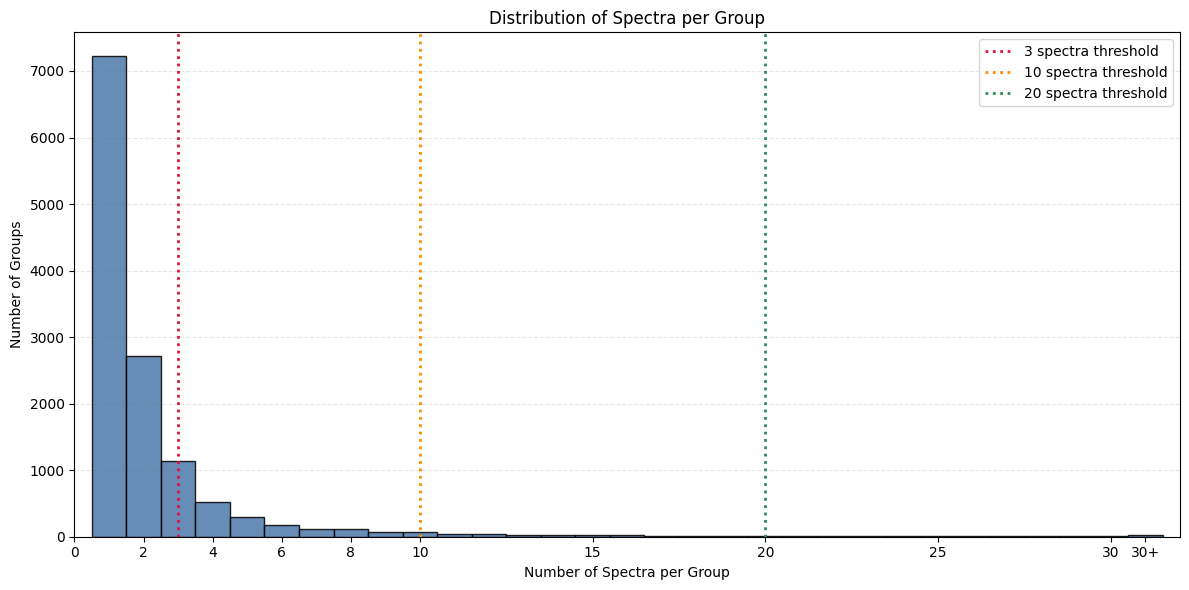

In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Load metadata from the full sample (fallback to metadata.pkl if full_metadata.pkl is absent).
candidate_paths = [
    '/home/msp25gd/Downloads/res/meta/full_metadata.pkl',
    '/home/msp25gd/Downloads/res/meta/metadata.pkl',
]

metadata_path = next((path for path in candidate_paths if os.path.exists(path)), None)
if metadata_path is None:
    raise FileNotFoundError('Could not find full_metadata.pkl or metadata.pkl in /home/msp25gd/Downloads/res/meta/')

meta_df = pd.read_pickle(metadata_path).copy()

# Resolve the column that identifies groups.
group_col = None
for col in ['Reduced', 'reduced', 'New Groups']:
    if col in meta_df.columns:
        group_col = col
        break
if group_col is None:
    raise KeyError('Could not find a grouping column (Reduced/reduced/New Groups).')

# Count spectra per group for ALL groups in the sample.
group_sizes = meta_df.groupby(group_col, dropna=False).size().rename('spectra_per_group')

total_groups = int(group_sizes.shape[0])
mean_size = float(group_sizes.mean())
median_size = float(group_sizes.median())

pct_below_3 = 100.0 * float((group_sizes < 3).mean())
pct_below_10 = 100.0 * float((group_sizes < 10).mean())
pct_below_20 = 100.0 * float((group_sizes < 20).mean())

summary_text = (
    'All-group distribution summary\n'
    '------------------------------\n'
    f'Metadata source: {metadata_path}\n'
    f'Total number of groups: {total_groups}\n'
    f'Mean spectra per group: {mean_size:.2f}\n'
    f'Median spectra per group: {median_size:.2f}\n'
    f'Percentage of groups with < 3 spectra: {pct_below_3:.2f}%\n'
    f'Percentage of groups with < 10 spectra: {pct_below_10:.2f}%\n'
    f'Percentage of groups with < 20 spectra: {pct_below_20:.2f}%'
 )
print(summary_text)

# Put all values above 30 into one overflow bin.
plot_values = group_sizes.values.astype(float).copy()
plot_values[plot_values > 30] = 31

# Bins: 1-width bins for 1..30 plus one overflow bin at 30+ (value 31).
bins = np.arange(0.5, 32.5, 1)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(plot_values, bins=bins, color='#4C78A8', edgecolor='black', alpha=0.85)

ax.axvline(3, color='crimson', linestyle=':', linewidth=2, label='3 spectra threshold')
ax.axvline(10, color='darkorange', linestyle=':', linewidth=2, label='10 spectra threshold')
ax.axvline(20, color='seagreen', linestyle=':', linewidth=2, label='20 spectra threshold')

# Start the chart at (0, 0) and keep plain numeric x labels.
ax.set_xlim(left=0, right=32)
ax.set_ylim(bottom=0)
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.ticklabel_format(style='plain', axis='x')

# Custom ticks with final overflow label.
xticks = [0, 2, 4, 6, 8, 10, 15, 20, 25, 30, 31]
xlabels = ['0', '2', '4', '6', '8', '10', '15', '20', '25', '30', '30+']
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)

ax.set_xlabel('Number of Spectra per Group')
ax.set_ylabel('Number of Groups')
ax.set_title('Distribution of Spectra per Group')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.legend()

save_dir = '/home/msp25gd/ResearchProjectMSc/Images/finalOtherImages'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'distribution_of_spectra_per_group.png')
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f'Saved figure to: {save_path}')

plt.tight_layout()
plt.show()